In [ ]:
# !pip install tensorflow-io

ERROR: Could not find a version that satisfies the requirement tensorflow-io (from versions: none)
ERROR: No matching distribution found for tensorflow-io


In [5]:
#importing necessary libraries
import tensorflow as tf
import tensorflow_io as tfio
#loading and reading the audio file.
audio_data = tfio.audio.AudioIOTensor('audio.wav')
print(audio_data)
print(audio_data.shape)
print(audio_data.rate)

<AudioIOTensor: shape=[66150     1], dtype=<dtype: 'int16'>, rate=22050>
tf.Tensor([66150     1], shape=(2,), dtype=int64)
tf.Tensor(22050, shape=(), dtype=int32)


In [6]:
#perform slicing
audio_sl = audio_data[6:]
print('Shape After Slicing :',audio_sl.shape)

#last dimension is ignored.
audio_t = tf.squeeze(audio_sl, axis=[-1])
print('Shape After squeezing:',audio_t.shape)

#to play the audio,
from IPython.display import Audio
Audio(audio_t.numpy(), rate=audio_data.rate.numpy())

Shape After Slicing : (66144, 1)
Shape After squeezing: (66144,)


tf.Tensor(
[ 9.15555283e-05  2.13629566e-04  1.52592547e-04 ... -3.66222113e-04
 -1.30314035e-02 -6.92770164e-03], shape=(66144,), dtype=float32)


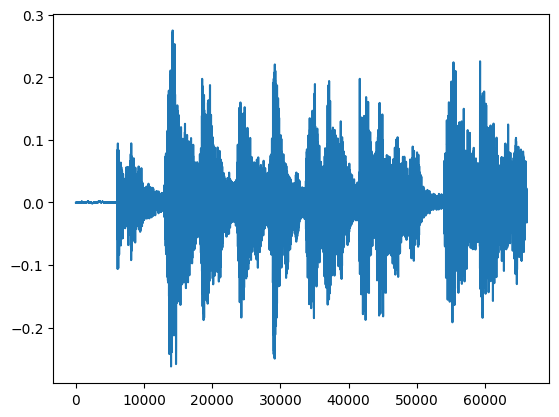

In [7]:
# convert tensor to float datatype,.
tensor = tf.cast(audio_t, tf.float32) / 32767.0
print(tensor)

#plot the graph.
import matplotlib.pyplot as plt
plt.figure()
plt.plot(tensor.numpy())
plt.show()

Trimmed : tf.Tensor([13840 59291], shape=(2,), dtype=int64)
START:13840,
STOP :59291
Trimmed Audio shape: (45451,)


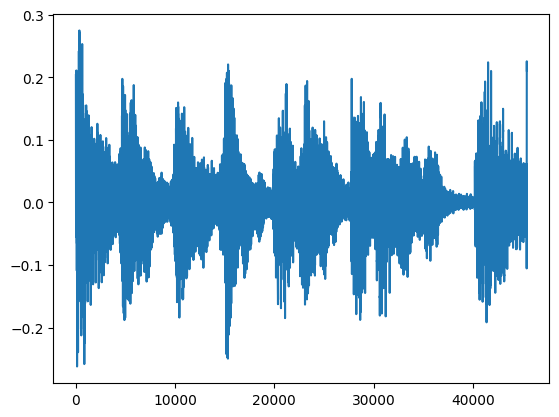

In [8]:
# Trim silence from the beginning and end of the audio signal
trimed = tfio.audio.trim(tensor,
						axis=0,
						epsilon=0.2)
print('Trimmed :',trimed)

#Mention the stating and ending limit
start = trimed[0]
stop = trimed[1]
print("START:{},\nSTOP :{}".format(start.numpy(),
								stop.numpy()))
trimmed_audio = tensor[start:stop]
print('Trimmed Audio shape:',trimmed_audio.shape)

plt.figure()
plt.plot(trimmed_audio.numpy())
#to play the audio,
Audio(trimmed_audio.numpy(),
	rate=audio_data.rate.numpy())

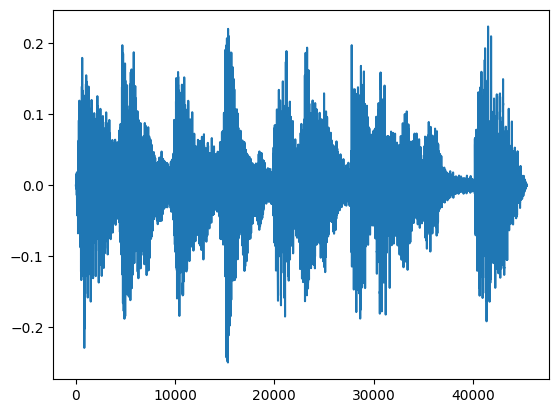

In [9]:
#Apply a fade-in and fade_out effect with a duration
audio_fade = tfio.audio.fade(trimmed_audio,
							fade_in=1000,
							fade_out=2000,
							mode="logarithmic")

plt.figure()
#plotting the faded audio.
plt.plot(audio_fade.numpy())
#to plat the audio
Audio(audio_fade.numpy(),
	rate=audio_data.rate.numpy())

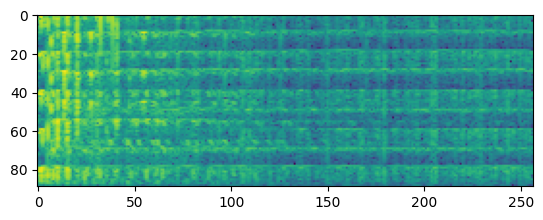

In [10]:
# Convert to spectrogram
spectrogram = tfio.audio.spectrogram(audio_fade,
									nfft=512,
									window=512,
									stride=512)

plt.figure()
#plotting spectrogram
plt.imshow(tf.math.log(spectrogram).numpy())
plt.show()

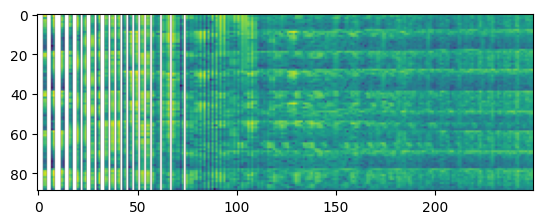

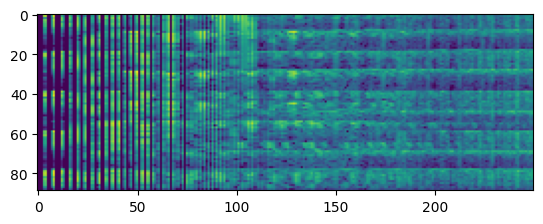

In [11]:
# Convert spectrogram to mel spectrogram with 250 mel bands
spectrogram_mel = tfio.audio.melscale(spectrogram, rate=16000, mels=250, fmin=0, fmax=7000)
plt.figure()
plt.imshow(tf.math.log(spectrogram_mel).numpy())

#Convert spectrogram to decibel scale with top_db=70
spectrogram_dbscale = tfio.audio.dbscale(spectrogram_mel, top_db=70)
plt.figure()

plt.imshow(spectrogram_dbscale.numpy())
plt.show()

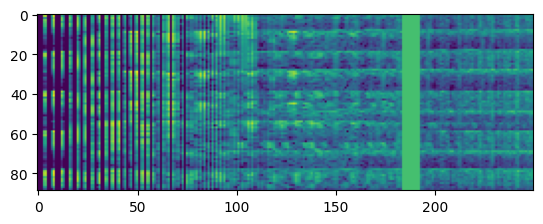

In [12]:
# Apply frequency masking with
# a max mask width of 100 frequency bins
spec_freq_mask = tfio.audio.freq_mask(spectrogram_dbscale, param=100)
plt.figure()
plt.imshow(spec_freq_mask.numpy())
plt.show()

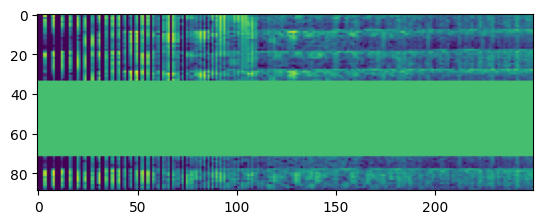

In [13]:
# Apply time masking with
# a max mask width of 50 time steps
audio_time_masked = tfio.audio.time_mask(spectrogram_dbscale,
										param=50)
plt.figure()
plt.imshow(audio_time_masked.numpy())
plt.show()